In [1]:
#pip install pandas

In [2]:
import pandas as pd

df = pd.DataFrame({
    'temperature': [10, 7, 4, 0],
    'sales':[30, 50, 60, 80]
})

display(df)

,temperature,sales
0,10,30
1,7,50
2,4,60
3,0,80


In [ ]:
a = -4# 기울기
b = 80# 절편

for i in range(len(df)):
    x = df.loc[i, 'temperature']#   i번째 행의 temperature(기온) 값 하나 추출
    pred = a * x + b#   pred = a, b로 예측한 값(예측값 = a * x + b)
    print(f'X = {x}일 때 예측값 = {a} * {x} + {b} = {pred}')

X = 10일 때 예측값 = -4 * 10 + 80 = 40
X = 7일 때 예측값 = -4 * 7 + 80 = 52
X = 4일 때 예측값 = -4 * 4 + 80 = 64
X = 0일 때 예측값 = -4 * 0 + 80 = 80


In [ ]:
a = -4
b = 80

#   df의 각 행을 하나씩 꺼내면서 예측값과 오차 계산
#   (이 셀에서는 df.loc로 행 번호 i를 이용해 값을 하나씩 꺼냄)
for i in range(len(df)):
    x = df.loc[i, 'temperature']    #   입력값  x: 기온(i번째 행)
    y = df.loc[i, 'sales']          #   정답    y: 실제 판매량(i번째 행)
    pred = a * x + b                #   예측값 계산(a * x + b)
    error = pred - y                #   오차 = 실제값 - 예측값
    
    print(f'X = {x}, 실제값 = {y}, 예측값 = {pred}, 오차 = {pred} - {y} = {error}')
    print('=' * 30)

X = 10, 실제값 = 30, 예측값 = 40, 오차 = 40 - 30 = 10
X = 7, 실제값 = 50, 예측값 = 52, 오차 = 52 - 50 = 2
X = 4, 실제값 = 60, 예측값 = 64, 오차 = 64 - 60 = 4
X = 0, 실제값 = 80, 예측값 = 80, 오차 = 80 - 80 = 0


In [ ]:
a = -4
b = 80

square_sum = 0  #   오차 제곱 더해서 담아 둘 변수(시작: 0)

#   모든 행을 순회 → '오차를 제곱한 값'을 square_sum
for i in range(len(df)):
    x = df.loc[i, 'temperature']
    y = df.loc[i, 'sales']
    pred = a * x + b                            #   예측값
    error = pred - y                            #   오차 = 실제값 - 예측값
    error_square = error * error                #   오차 제곱(=error ** 2): 음수 → 양수
    square_sum = square_sum + error_square      #   제곱들을 차곡차곡 가산
    
n = len(df)                                     #   데이터(행) 개수: 여기서는 4
cost = square_sum / n                           #   Cost = 오차 제곱의 평균(제곱들의 합 ÷ 개수)

print(f'오차 제곱 합: {square_sum}')
print(f'데이터 개수: {n}')
print(f'Cost: {cost:.4f}')                      #   소숫점 4자리로 출력

오차 제곱 합: 120
데이터 개수: 4
Cost: 30.0000


In [ ]:
def calculate_cost(a, b):
    """
    ----- calculate_cost 함수 설명 -----
    입력값 :
        a : 직선의 기울기
        b : 직선의 절편
    처리 과정:
        1) 모든 데이터에 대해 예측값을 계산한다.
        2) 실제값과 비교해 오차를 계산한다.(오차 = 실제값 - 예측값)
        3) 오차를 제곱한다.
        4) 오차 제곱의 평균을 Cost로 계산한다.
    반환값:
        cost : 현재 a, b가 얼마나 좋은지(얼마나 안 틀렸는지) 나타내는 숫자
    -----------------------------------
    """
    square_sum = 0                              #   오차 제곱의 합(시작: 0)
    for i in range(len(df)):
        x = df.loc[i, 'temperature']
        y = df.loc[i, 'sales']
        pred = a * x + b                        #   1) 예측값을 계산하고
        error = y - pred                        #   2) 오차를 계산하고 (오차 = 실제값 - 예측값)
        error_square = error * error            #   3) 오차를 제곱하고
        square_sum = square_sum + error_square  #   4) 오차 제곱을 가산
        
    n = len(df)                               #   데이터 개수
    cost = square_sum / n                       #   5) 오차 제곱의 평균 = Cost
    return cost                                 #   6) 계산한 Cost를 돌려준다.

#   함수가 잘 동작하는지 확인: a = -4, b = 80일 때 Cost (위에서 직접 구한 30.0이 나와야 함)
print('calculate_cost(-4, 80) =', calculate_cost(-4, 80))

calculate_cost(-4, 80) = 30.0


In [ ]:
#   함수를 사용하면 직선 하나의 Cost를 한 줄로 구할 수 있습니다.
cost1 = calculate_cost(-4, 80)      #   첫 번째 직선 Y = -4X + 80 의 Cost
cost2 = calculate_cost(-4.9, 81)    #   두 번째 직선 Y = -4.9X + 81 의 Cost

#   두 직선 중 Cost가 더 작은 쪽이 데이털르 더 잘 설명하는 직선입니다.
print(f'Y = -4X + 80의 Cost: {cost1:.4f}')
print(f'Y = -4.9X + 81의 Cost: {cost2:.4f}')

Y = -4X + 80의 Cost: 30.0000
Y = -4.9X + 81의 Cost: 4.4625


In [ ]:
#   a_values : 비교해볼 여러 개의 a(기울기) 값들을 리스트로 모아둔 것
a_values = [-6, -5 , -4, -3, -2]
b = 80  #   b(절편)는 80으로 고정하고, a만 변화

#   cost_values : 각 a에 대한 Cost를 저장해 둘 빈 리스트 (뒤에서 그래프 y축으로 사용)
cost_values = []

#   a_values 안의 값을 하나씩 a에 넣어가며 Cost를 계산합니다.
for a in a_values:
    cost = calculate_cost(a, b)     #   각 a 값에 대한 Cost 계산
    cost_values.append(cost)        #   계산한 Cost를 리스트 맨 뒤에 추가(저장)
    print(f'a = {a}, b = {b}, Cost = {cost:.4f}')

a = -6, b = 80, Cost = 65.0000
a = -5, b = 80, Cost = 6.2500
a = -4, b = 80, Cost = 30.0000
a = -3, b = 80, Cost = 136.2500
a = -2, b = 80, Cost = 325.0000


In [9]:
#!pip install matplotlib

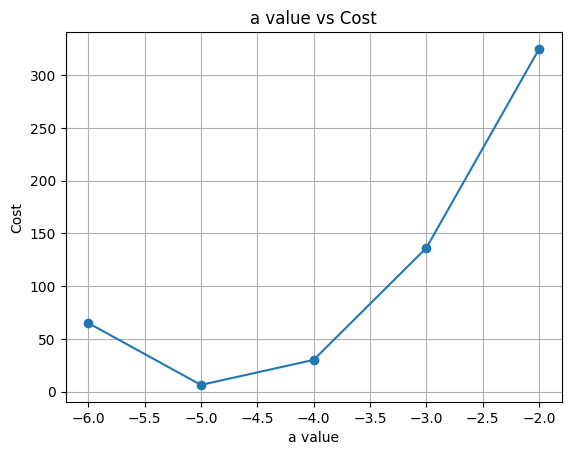

In [ ]:
import matplotlib.pyplot as plt                 #   matplotlib: 그래프를 그리는 도구(plt라는 짧은 이름으로 사용)

plt.figure()                                    #   새 그래프 판(도화지)을 하나 만듭니다.
"""
plot(x축 값, y축 값): a_values를 x축, cost_values를 y축으로 점을 찍고 선으로 잇습니다.
   marker = 'o'    : 각 데이터 위치에 동그라미 점을 표시합니다.
"""
plt.plot(a_values, cost_values, marker = 'o')
plt.title('a value vs Cost')    #   그래프 제목
plt.xlabel('a value')           #   x축 이름: a 값
plt.ylabel('Cost')              #   y축 이름: Cost
plt.grid(True)                  #   눈금자(격자) 표시 → 값을 읽기 쉬워집니다.
plt.show()                      #   지금까지 그린 그래프를 화면에 보여줍니다.

In [ ]:
b = 80  #   b 는  80으로 고정하고, a만 손으로 조금씩 바꿔봅니다.

#   a를 -4 → -4.5 → -5로 바꿔보면서 그때그때 Cost가 어떻게 변하는지 확인합니다.
a = -4
cost = calculate_cost(a, b)     #   현재 a, b로 Cost 계산
print(f'a = {a}, b = {b}, Cost = {cost:.4f}')

a = -4.5
cost = calculate_cost(a, b)     #   a를 바꾼 뒤 다시 Cost 계산
print(f'a = {a}, b = {b}, Cost = {cost:.4f}')

a = -5
cost = calculate_cost(a, b)     #   a를 또 바꾼 뒤 다시 Cost 계산
print(f'a = {a}, b = {b}, Cost = {cost:.4f}')

a = -4, b = 80, Cost = 30.0000
a = -4.5, b = 80, Cost = 7.8125
a = -5, b = 80, Cost = 6.2500


In [ ]:
#   시작 직선 : Y = -4X + 80
a = -4
b = 80
learning_rate = 0.001       #   학습률(보폭) : 한 번에 조금씩만 움직이도록 작은 값 사용
epochs = 1000               #   전체 데이터를 1,000번 반복해서 학습

n = len(df)               # 데이터(행) 개수
cost_history = []           # 매 epoch의 Cost를 저장할 리스트(뒤에서 그래프로 그림)

#   학습 시작 전, 처음 직선의 값과 Cost를 기억해 둡니다.
#   (나중에 학습 전후를 비교할 때 사용합니다.)
initial_a = a
initial_b = b
initial_cost = calculate_cost(a, b)
print(f'학습 전 Cost: {initial_cost:.4f}')

학습 전 Cost: 30.0000


In [ ]:
#   epochs: 전체 데이터를 몇 번 반복해서 학습할지 정하는 값
#   예: epochs = 1000이면, 전체 데이터를 1,000번 반복 → a, b를 수정
for epoch in range(epochs):
    #   grad_a: a를 수정하기 위해 사용할 Gradient 누적값
    #   grad_b: b를 수정하기 위해 사용할 Gradient 누적값
    #   매 반복(epoch)마다 새로 계산해야 하므로 0으로 초기화
    grad_a = 0
    grad_b = 0
    
    #   전체 데이터를 한 행씩 확인
    for i in range(len(df)):
        x = df.loc[i, 'temperature']    #   입력값
        y = df.loc[i, 'sales']          #   실제값
        
        #   현재 a, b로 예측값 계산
        #   H(x) = ax + b
        pred = a * x + b
        
        #   Gradient 계산에는 미분 결과인 H(x) - y를 사용
        #   즉, 예측값 - 실제값
        pred_minus_actual = pred - y
        
        #   a에 대한 Gradient 누적
        #   δcost / δa = x * (H(x) - y)
        grad_a = grad_a + pred_minus_actual * x
        #   b에 대한 Gradient 누적
        #   δcost / δb = H(x) - y
        grad_b = grad_b + pred_minus_actual
        
    #   전체 데이터 개수로 나누어 평균 Gradient 계산
    n = len(df)
    grad_a = grad_a / n
    grad_b = grad_b / n
    
    #   Gradient Descent 공식으로 a, b 수정
    #   새 값 = 현재 값 - learning_rate * Gradient
    a = a - learning_rate * grad_a
    b = b - learning_rate * grad_b
    
    #   수정된 a, b → 현재 Cost 계산 후 저장
    cost = calculate_cost(a, b)
    cost_history.append(cost)
    
    #   100번 반복마다 중간 결과 출력
    if epoch % 100 == 0:
        print(f'epoch = {epoch}, Cost = {cost:.4f}, a = {a:.4f}, b = {b:.4f}')

epoch = 0, Cost = 27.9005, a = -4.0325, b = 79.9960
epoch = 100, Cost = 4.4233, a = -4.7666, b = 79.9185
epoch = 200, Cost = 4.4137, a = -4.7787, b = 79.9331
epoch = 300, Cost = 4.4089, a = -4.7808, b = 79.9484
epoch = 400, Cost = 4.4044, a = -4.7827, b = 79.9632
epoch = 500, Cost = 4.4002, a = -4.7846, b = 79.9776
epoch = 600, Cost = 4.3963, a = -4.7864, b = 79.9916
epoch = 700, Cost = 4.3926, a = -4.7881, b = 80.0050
epoch = 800, Cost = 4.3891, a = -4.7898, b = 80.0181
epoch = 900, Cost = 4.3859, a = -4.7914, b = 80.0307


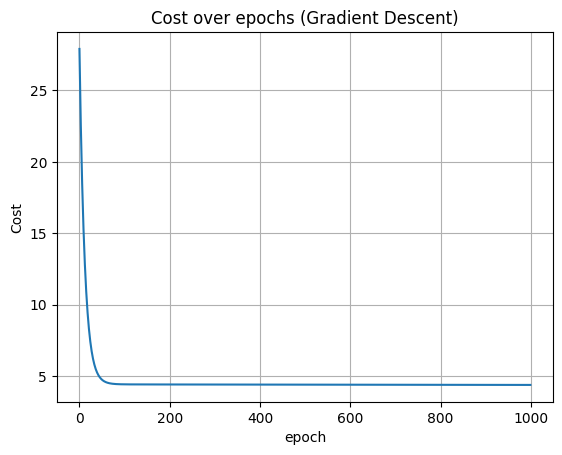

In [ ]:
import matplotlib.pyplot as plt #   (위에서 이미 import 했지만, 이 셀만 봐도 알 수 있도록 재차 적어줍니다.)

plt.figure()                                        #   새 그래프 판 만들기
"""
x축: epoch 번호(0, 1, 2, ...)
y축: 해당 epoch의 Cost
range(len(cost_history)): 0부터 저장된 Cost 개수 만큼의 번호를 만들어 줍니다.
"""
plt.plot(range(len(cost_history)), cost_history)    
plt.title('Cost over epochs (Gradient Descent)')    #   그래프 제목
plt.xlabel('epoch')                                 #   x축 이름: 반복 횟수
plt.ylabel('Cost')                                  #   y축 이름: Cost
plt.grid(True)                                      #   눈금선 표시
plt.show()                                          #   그래프 화면에 출략

In [ ]:
"""
학습 전 값: 11번 셀에서 학습 시작 전에 저장해 둔 값 사용
    initial_a
    initial_b
    initial_cost
학습 후 값: 11번 셀 반복문 끝난 뒤 남아있는 a, b → 곧 학습된 값
"""
final_a = a
final_b = b
final_cost = calculate_cost(final_a, final_b)   #   학습된 a, b의 Cost

print('학습 전')
print(f'a = {initial_a: .4f}')
print(f'b = {initial_b: .4f}')
print(f'Cost = {initial_cost: .4f}')

print('\n학습 후')
print(f'a = {final_a: .4f}')
print(f'b = {final_b: .4f}')
print(f'Cost = {final_cost: .4f}')

학습 전
a = -4.0000
b =  80.0000
Cost =  30.0000

학습 후
a = -4.7930
b =  80.0428
Cost =  4.3829
